In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("../Dataset/cleaned_accidents.csv")

In [3]:
df.head()

,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,City,State,Start_Lat,Start_Lng,Hour,Month,Day
0,3,2016-02-08 05:46:00,36.9,91.0,10.0,Light Rain,Dayton,OH,39.865147,-84.058723,5,2,8
1,2,2016-02-08 06:07:59,37.9,100.0,10.0,Light Rain,Reynoldsburg,OH,39.928059,-82.831184,6,2,8
2,2,2016-02-08 06:49:27,36.0,100.0,10.0,Overcast,Williamsburg,OH,39.063148,-84.032608,6,2,8
3,3,2016-02-08 07:23:34,35.1,96.0,9.0,Mostly Cloudy,Dayton,OH,39.747753,-84.205582,7,2,8
4,2,2016-02-08 07:39:07,36.0,89.0,6.0,Mostly Cloudy,Dayton,OH,39.627781,-84.188354,7,2,8


In [7]:
df.isnull().sum()

Severity                  0
Start_Time                0
Temperature(F)       152129
Humidity(%)          161651
Visibility(mi)       164733
Weather_Condition    161636
City                    237
State                     0
Start_Lat                 0
Start_Lng                 0
Hour                      0
Month                     0
Day                       0
dtype: int64

## Median
Filling Median in Missing Values

In [15]:
df['Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].median())
df['Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Weather_Condition'] = df['Weather_Condition'].fillna(df['Weather_Condition'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])


In [16]:
df.isnull().sum()

Severity             0
Start_Time           0
Temperature(F)       0
Humidity(%)          0
Visibility(mi)       0
Weather_Condition    0
City                 0
State                0
Start_Lat            0
Start_Lng            0
Hour                 0
Month                0
Day                  0
weather_condition    0
Weather_condition    0
dtype: int64

In [17]:
df['Is_Weekend'] = df['Day'].isin(['Saturday', 'Sunday']).astype(int)

In [18]:
def get_time_period(hour):

    if 5 <= hour < 12:
        return 'Morning'

    elif 12 <= hour < 17:
        return 'Afternoon'

    elif 17 <= hour < 21:
        return 'Evening'

    else:
        return 'Night'

In [21]:
df['Time_Period'] =df['Hour'].apply(get_time_period)


In [25]:
df[['Hour', 'Time_Period']].head()

,Hour,Time_Period
0,5,Morning
1,6,Morning
2,6,Morning
3,7,Morning
4,7,Morning


In [26]:
df.drop(columns=['Start_Time'], inplace=True)

In [27]:
df.select_dtypes(include=['object']).columns

C:\Users\shiva\AppData\Local\Temp\ipykernel_11384\549554427.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


Index(['Weather_Condition', 'City', 'State', 'weather_condition',
       'Weather_condition', 'Time_Period'],
      dtype='str')

In [28]:
df.columns

Index(['Severity', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
       'Weather_Condition', 'City', 'State', 'Start_Lat', 'Start_Lng', 'Hour',
       'Month', 'Day', 'weather_condition', 'Weather_condition', 'Is_Weekend',
       'Time_Period'],
      dtype='str')

In [29]:
df.drop(columns=['weather_condition', 'Weather_condition'], inplace=True)

In [30]:
df.columns

Index(['Severity', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
       'Weather_Condition', 'City', 'State', 'Start_Lat', 'Start_Lng', 'Hour',
       'Month', 'Day', 'Is_Weekend', 'Time_Period'],
      dtype='str')

In [31]:
df.select_dtypes(include=['object']).columns

C:\Users\shiva\AppData\Local\Temp\ipykernel_11384\549554427.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


Index(['Weather_Condition', 'City', 'State', 'Time_Period'], dtype='str')

In [32]:
encoder = LabelEncoder()

In [33]:
categorical_columns = ['Weather_Condition', 'City', 'Time_Period', 'Day', 'State']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [34]:
df.head()

,Severity,Temperature(F),Humidity(%),Visibility(mi),Weather_Condition,City,State,Start_Lat,Start_Lng,Hour,Month,Day,Is_Weekend,Time_Period
0,3,36.9,91.0,10.0,62,2894,33,39.865147,-84.058723,5,2,7,0,2
1,2,37.9,100.0,10.0,62,10195,33,39.928059,-82.831184,6,2,7,0,2
2,2,36.0,100.0,10.0,88,13347,33,39.063148,-84.032608,6,2,7,0,2
3,3,35.1,96.0,9.0,85,2894,33,39.747753,-84.205582,7,2,7,0,2
4,2,36.0,89.0,6.0,85,2894,33,39.627781,-84.188354,7,2,7,0,2


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

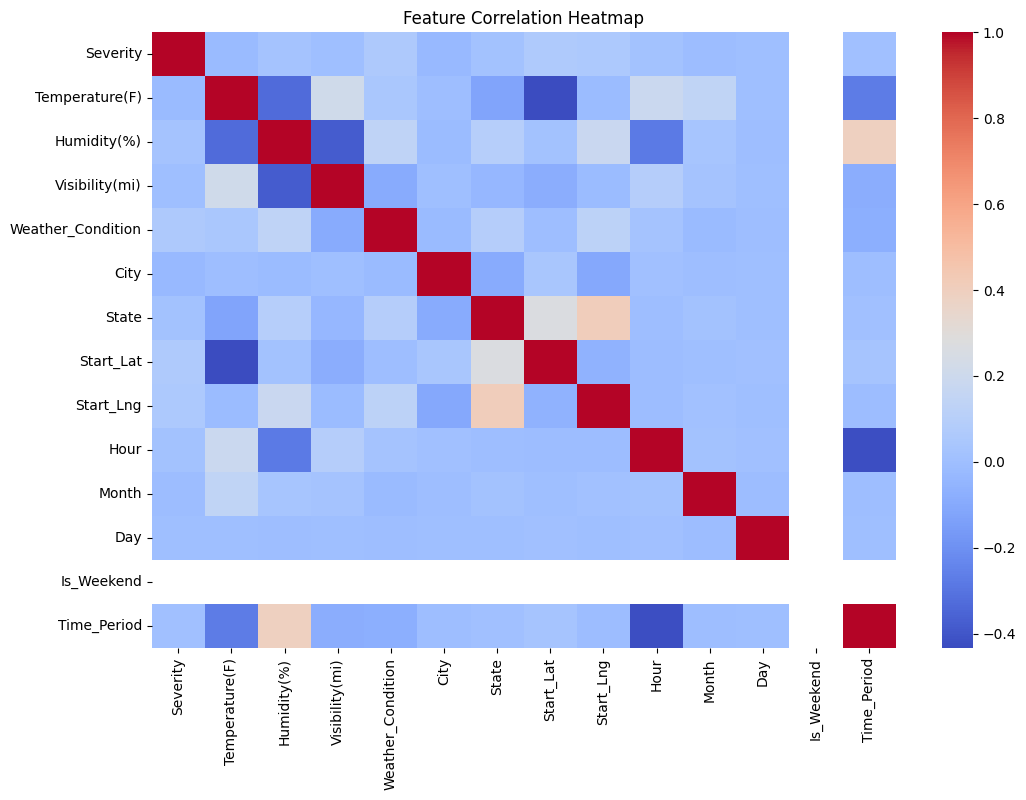

In [36]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.savefig("../Images/feature_correlation_heatmap.png")
plt.show()

In [37]:
y =df['Severity']

In [38]:
X = df.drop(columns=['Severity'])

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5792321, 13) (1448081, 13) (5792321,) (1448081,)


In [41]:
df.to_csv("../Dataset/final_ml_dataset.csv", index=False)